1. 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2. 📥 Load Data

In [2]:
df = pd.read_csv("train.csv")
# target
y = df["price"]
X = df.drop(["price"], axis=1)


3. 🧹 Handle Missing Values

In [3]:
# fill numeric missing values
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# fill categorical missing values
cat_cols = X.select_dtypes(include="object").columns
X[cat_cols] = X[cat_cols].fillna("None")

In [4]:
binary_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning", "prefarea"
]

for col in binary_cols:
   X[col] = X[col].map({"yes":1,"no":0})
 

In [6]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,7420,4,1,2,1,1,1,0,1,2,0,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,unfurnished
541,2400,3,1,1,0,0,0,0,0,0,0,semi-furnished
542,3620,2,1,1,1,0,0,0,0,0,0,unfurnished
543,2910,3,1,1,0,0,0,0,0,0,0,furnished


In [7]:
X = pd.get_dummies(X, columns=["furnishingstatus"], drop_first=True)

In [8]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [9]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

In [10]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0,0


5. 📏 Train/Test Split

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6. 📊 Normalization (VERY important for NN)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# log transform target (recommended for house prices)
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

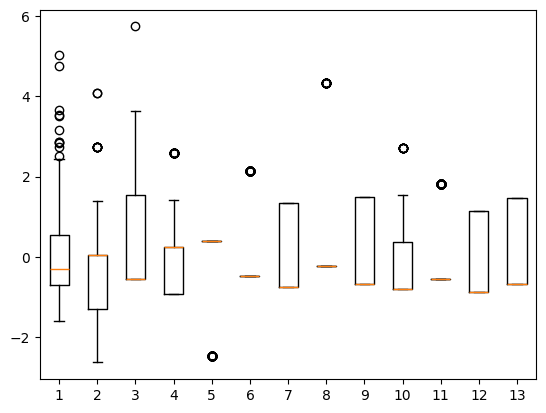

In [13]:
plt.boxplot(X_train)
plt.show()

In [14]:
X_train.shape

(436, 13)

7. 🔁 Convert to Torch Tensors

In [15]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

8. 🧱 Dataset Class

In [16]:
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

9. 📦 DataLoader

In [17]:
train_ds = HouseDataset(X_train, y_train)
val_ds = HouseDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

In [111]:
np.random.rand()

0.10797210722897699

In [112]:
alpha = -4*np.random.rand()
lr = 10.0**alpha
lr


0.0015046832964839682

10. 🧠 Neural Network Model

In [131]:
class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
          
            nn.Linear(32, 16),
            nn.ReLU(),
          
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HousePriceModel(X_train.shape[1]).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr ,momentum=0.90,weight_decay=0.01)  
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=100,   # every 10 epochs
#     gamma=0.5       # reduce LR by half
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # we minimize loss
    factor=0.5,        # reduce LR by half
    patience=5,        # wait 5 epochs before reducing
     )


12. 🔁 Training Loop

In [ ]:
train_losses = []
val_losses = []

epochs = 1000

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            val_loss += loss.item()
         

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    scheduler.step(val_loss)      
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

Epoch 1: Train=167.1349, Val=33.6578
Epoch 2: Train=21.0102, Val=12.2250
Epoch 3: Train=3.5298, Val=0.2410
Epoch 4: Train=0.6060, Val=0.7242
Epoch 5: Train=0.3288, Val=0.2578
Epoch 6: Train=0.1572, Val=0.1984
Epoch 7: Train=0.1249, Val=0.1885
Epoch 8: Train=0.1237, Val=0.1914
Epoch 9: Train=0.1234, Val=0.1869
Epoch 10: Train=0.1272, Val=0.1891
Epoch 11: Train=0.1248, Val=0.1950
Epoch 12: Train=0.1233, Val=0.1835
Epoch 13: Train=0.1254, Val=0.1884
Epoch 14: Train=0.1229, Val=0.1891
Epoch 15: Train=0.1220, Val=0.1862
Epoch 16: Train=0.1205, Val=0.1868
Epoch 17: Train=0.1207, Val=0.1809
Epoch 18: Train=0.1193, Val=0.1915
Epoch 19: Train=0.1206, Val=0.1816
Epoch 20: Train=0.1192, Val=0.1800
Epoch 21: Train=0.1189, Val=0.1857
Epoch 22: Train=0.1178, Val=0.1791
Epoch 23: Train=0.1183, Val=0.1907
Epoch 24: Train=0.1181, Val=0.1788
Epoch 25: Train=0.1145, Val=0.1743
Epoch 26: Train=0.1144, Val=0.1799
Epoch 27: Train=0.1129, Val=0.1742
Epoch 28: Train=0.1140, Val=0.1683
Epoch 29: Train=0.1087, 

KeyboardInterrupt: 

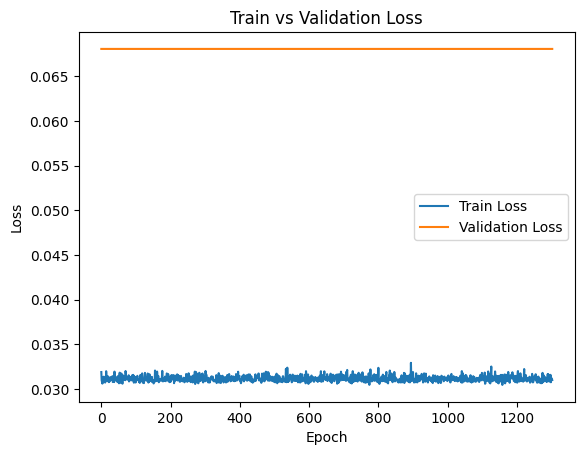

In [133]:
import matplotlib.pyplot as plt

plt.plot(train_losses[500:], label="Train Loss")
plt.plot(val_losses[500:], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

plt.legend()
plt.show()

In [134]:
from sklearn.metrics import mean_absolute_error
model.eval()
index = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
X_val = X_val.to(device)

with torch.no_grad():
    pred = model(X_val[index].unsqueeze(0))
   
pred_real = torch.expm1(pred).item()
print("Prediction:", pred_real)
actual = torch.expm1(y_val[index]).item() 
print(f"Actual is {actual}")

percent_error = abs(pred_real-actual)/actual
print("Percent error:", percent_error)

  

Prediction: 3945789.75
Actual is 4060000.5
Percent error: 0.028130723136610452


In [135]:
model.eval()

with torch.no_grad():
    preds = model(X_val)

pred_real = torch.expm1(preds).to(device)
actual_real = torch.expm1(y_val).to(device)

mae = torch.mean(torch.abs(pred_real - actual_real))
rmse = torch.sqrt(torch.mean((pred_real - actual_real)**2))

print("Validation MAE:", mae.item())
print("Validation RMSE:", rmse.item())
 

Validation MAE: 998201.0625
Validation RMSE: 1386993.625


In [136]:
mae_ratio = mae.item() / actual_real.mean().item()
print(mae_ratio)
 

0.19933972779432282


In [137]:
actual_real.mean()

tensor(5007537., device='cuda:0')

In [129]:
baseline_mae = torch.mean(torch.abs(actual_real - actual_real.mean()))
baseline_ratio = baseline_mae / actual_real.mean()
print(baseline_ratio)
 

tensor(0.3540, device='cuda:0')


In [80]:
np.mean(np.abs(y-y.mean()))/y.mean()

np.float64(0.3022414007461246)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e31e817700>,
 'caps': [<matplotlib.lines.Line2D at 0x1e31e817d00>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e31e817520>],
 'medians': [<matplotlib.lines.Line2D at 0x1e31e834340>],
 'fliers': [<matplotlib.lines.Line2D at 0x1e31e834640>],
 'means': []}

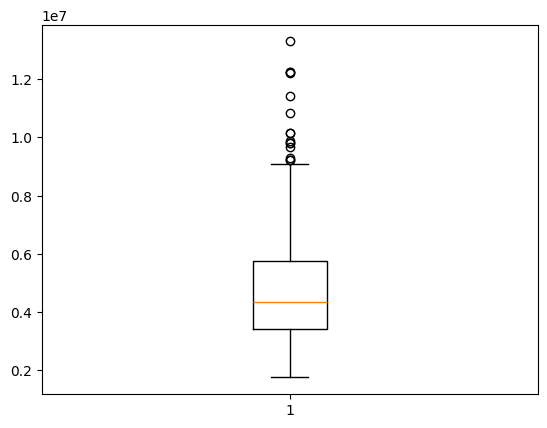

In [82]:
plt.boxplot(y)